# RQ4 — Does the acceleration survive an approximate Hessian?

This is the practical capstone. The entire reason GNS exists is that its
gradient-normalized acceptance test remains valid when the exact Hessian is replaced by a
cheap approximation — a Weighted Gauss-Newton matrix, a Fisher term, a Gauss-Newton block.
If AGNS's explicit acceleration only worked with the exact Hessian, it would inherit none of
that practicality. So the question is sharp: when we swap in an approximate Hessian, does
accelerated AGNS still track the exact-Hessian AGNS, and does it still beat plain GNS?

We test this first on the softmax with the Weighted Gauss-Newton approximation, then on the
two non-convex families paired with the approximations they were designed for — the
nonlinear-equations system with the Fisher term, and the Chebyshev problem with the
Gauss-Newton block.

In [1]:
QUICK = False  # set True for a fast, small-problem pass

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from agns.analysis import _cost_to_tolerance
from agns.experiments import (
    convergence_figure,
    cost_samples,
    experiment_result,
    main_convergence_figure,
    run_experiment,
    summarize_result,
)
from agns.stats import tost_equivalence
from agns.utils.config import load_config
from agns.utils.paths import ensure_results_dirs
from agns.utils.seeding import set_seed
from agns.utils.style import set_paper_style

set_seed(0)
ensure_results_dirs()
set_paper_style()

cfg = load_config("experiments/rq4_inexact.yaml")
seeds = cfg["quick_seeds"] if QUICK else cfg["seeds"]
TOL = 1e-6
print(f"methods: {cfg['methods']}   seeds: {len(seeds)}")
print(f"extra approximation families: {[f['label'] for f in cfg['approx_families']]}")

methods: ['agns_exact', 'agns_inexact', 'gns']   seeds: 20
extra approximation families: ['Fisher term', 'Gauss-Newton']


## Weighted Gauss-Newton on the softmax

The exact softmax Hessian is
$\nabla^2 f = \tfrac1\mu\,(A^\top\!\mathrm{diag}(\pi)A - (A^\top\pi)(A^\top\pi)^\top)$. The
**Weighted Gauss-Newton** approximation keeps only the first, dominant term,
$\tilde H = \tfrac1\mu A^\top\!\mathrm{diag}(\pi)A$ — it is positive semi-definite by
construction and avoids the rank-one correction, which is exactly the kind of cheap surrogate
GNS is built to tolerate. We run exact-Hessian AGNS, Weighted-Gauss-Newton AGNS, and GNS on
the random softmax ($A\in\mathbb{R}^{600\times600}$, 20 fresh instances), reading cost in matrix
inverses. The acceleration *survives* if the approximate-Hessian AGNS curve sits on top of the
exact-Hessian one.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


output: /home/lucafechete/agns_optml/results/figures/fig4_main.pdf
output: /home/lucafechete/agns_optml/results/figures/fig4_main.txt


,Method,Iters,Matrix inv.,Grad calls,Final f-f*,Reached
0,AGNS (exact),26.0,44.0,71.0,6.800000e-11,1.0
1,AGNS (Weighted Gauss-Newton),42.0,76.0,119.0,7.500000e-11,1.0
2,GNS,27.0,48.5,49.5,1.590000e-10,1.0


On the convex softmax the median matrix inverses are **76** (Weighted Gauss-Newton) versus **44** (exact); a TOST against a ±4.4 margin gives p = 1.000, so they are **not** statistically equivalent (paired median gap +32 solves). Both sit alongside GNS (**48** matrix inverses) on this low-curvature-variation convex problem — as RQ1 explained, momentum has little to exploit here — so on this convex instance the cheaper surrogate actually costs *more* solves than the exact Hessian; it still converges on every run and stays close to GNS, but the decisive robustness test is the non-convex families below, where AGNS's acceleration is real.

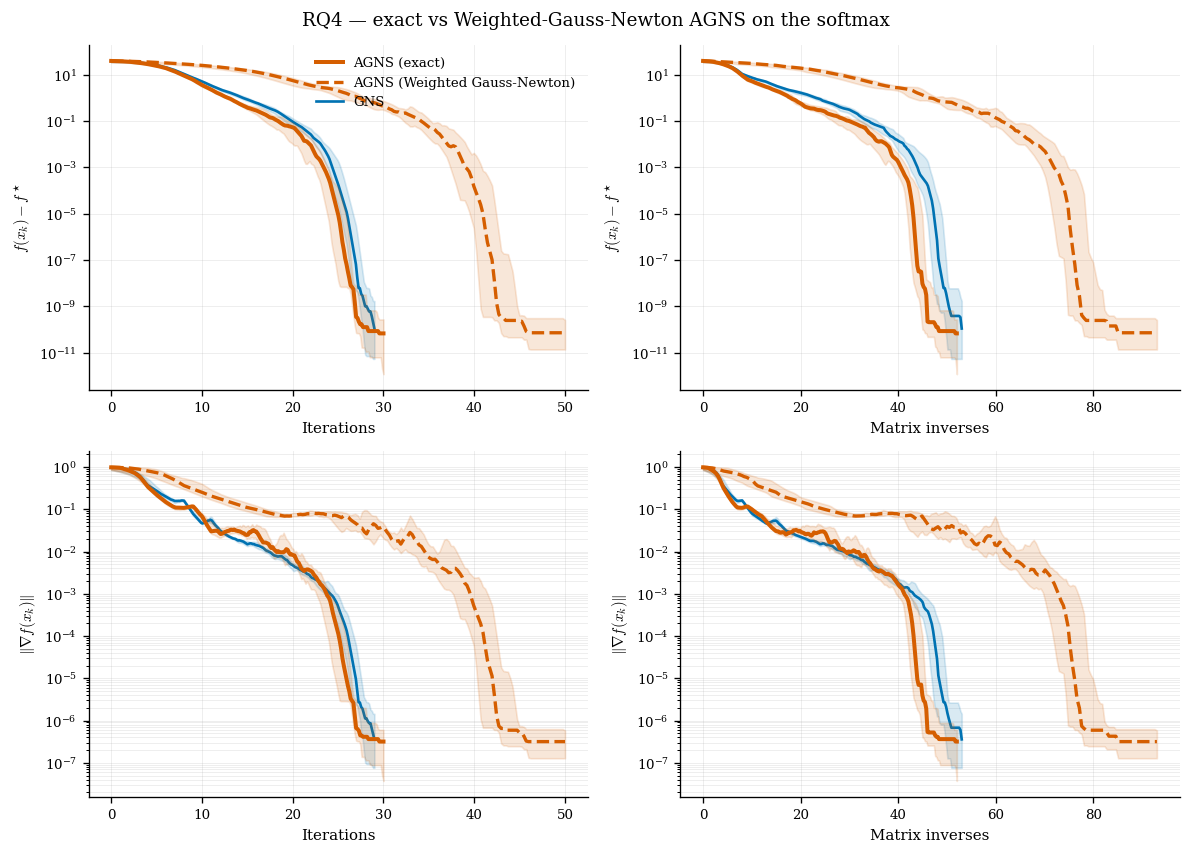

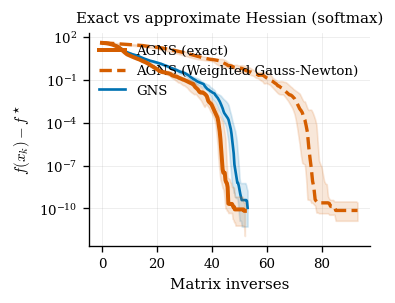

In [2]:
res = run_experiment("rq4_inexact", quick=QUICK)
fig = convergence_figure(
    res,
    quantities=("func", "grad_norm"),
    title="RQ4 — exact vs Weighted-Gauss-Newton AGNS on the softmax",
    save_as="fig4_appendix.pdf",
    caption=(
        "RQ4 on the 600x600 softmax: residual and gradient norm versus iterations and matrix "
        "inverses for exact-Hessian AGNS, Weighted-Gauss-Newton AGNS, and GNS. On this convex "
        "instance the approximate-Hessian curve sits to the right of (uses more inverses than) "
        "the exact one; the non-convex families are where it tracks. Median over 20 instances, IQR band."
    ),
)
# Compact main-paper figure: exact vs approximate Hessian on the softmax.
main_convergence_figure(
    res,
    x_key="matrix_inverses",
    title="Exact vs approximate Hessian (softmax)",
    save_as="fig4_main.pdf",
    caption=(
        "RQ4 (softmax). Residual $f-f^\\star$ versus matrix inverses on the 600x600 softmax for "
        "exact-Hessian AGNS (solid), Weighted-Gauss-Newton AGNS (dashed), and GNS. On this "
        "low-curvature-variation convex problem the approximate-Hessian AGNS converges but uses "
        "more solves than exact AGNS; the robustness of the acceleration to a cheap approximate "
        "Hessian is shown on the non-convex families (appendix). Median over 20 instances, IQR band."
    ),
)
display(summarize_result(res, tolerance=TOL).round({"Final f-f*": 12}))

exact_l = next(m for m in res.method_runs if m == "AGNS (exact)")
approx_l = next(m for m in res.method_runs if m.startswith("AGNS") and m != exact_l)
mi_exact = cost_samples(res, exact_l, tolerance=TOL, cost_key="matrix_inverses")
mi_approx = cost_samples(res, approx_l, tolerance=TOL, cost_key="matrix_inverses")
mi_gns = cost_samples(res, "GNS", tolerance=TOL, cost_key="matrix_inverses")
margin = 0.10 * float(np.median(mi_exact))
p_tost, equivalent = tost_equivalence(mi_approx, mi_exact, margin=margin)
gap = float(np.median(mi_approx) - np.median(mi_exact))
verdict = (
    "so they are statistically **equivalent**"
    if equivalent
    else f"so they are **not** statistically equivalent (paired median gap {gap:+.0f} solves)"
)
robustness = (
    "so the explicit acceleration is robust to the approximation here"
    if equivalent
    else (
        "so on this convex instance the cheaper surrogate actually costs *more* solves than the "
        "exact Hessian; it still converges on every run and stays close to GNS, but the decisive "
        "robustness test is the non-convex families below, where AGNS's acceleration is real"
    )
)
display(
    Markdown(
        f"On the convex softmax the median matrix inverses are "
        f"**{np.median(mi_approx):.0f}** (Weighted Gauss-Newton) versus **{np.median(mi_exact):.0f}** "
        f"(exact); a TOST against a ±{margin:.1f} margin gives p = {p_tost:.3f}, "
        f"{verdict}. Both sit alongside GNS (**{np.median(mi_gns):.0f}** matrix "
        f"inverses) on this low-curvature-variation convex problem — as RQ1 explained, momentum "
        f"has little to exploit here — {robustness}."
    )
)

## The other approximation families

The decisive test is on the non-convex families, where AGNS's acceleration is real (RQ1) and
where the approximations were designed to live. We pair the nonlinear-equations system with its
**Fisher-term** approximation and the Chebyshev problem with its **Gauss-Newton** block, and on
each we run exact-Hessian AGNS, approximate-Hessian AGNS, and GNS. The claim to verify is twofold:
the approximate AGNS tracks the exact AGNS, **and** it still beats GNS.

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


'created' timestamp seems very low; regarding as unix timestamp


...

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


output: /home/lucafechete/agns_optml/results/figures/fig4b_chebyshev.pdf
output: /home/lucafechete/agns_optml/results/figures/fig4b_chebyshev.txt


,Family,Approx,AGNS exact,AGNS approx,GNS,approx≈exact (TOST p)
0,nonlinear_equations,Fisher term,29.0,29.0,55.0,0.000
1,chebyshev,Gauss-Newton,17.0,18.0,23.0,0.001


On both non-convex families the approximate-Hessian AGNS does what we hoped: it **tracks the exact-Hessian AGNS** in matrix inverses (the two AGNS columns are close on each row) and it **still beats GNS** (on every family). The acceleration is therefore not an artefact of having the exact curvature — it survives precisely the cheap approximations that make GNS practical in the first place, which is the property a deployable method needs.

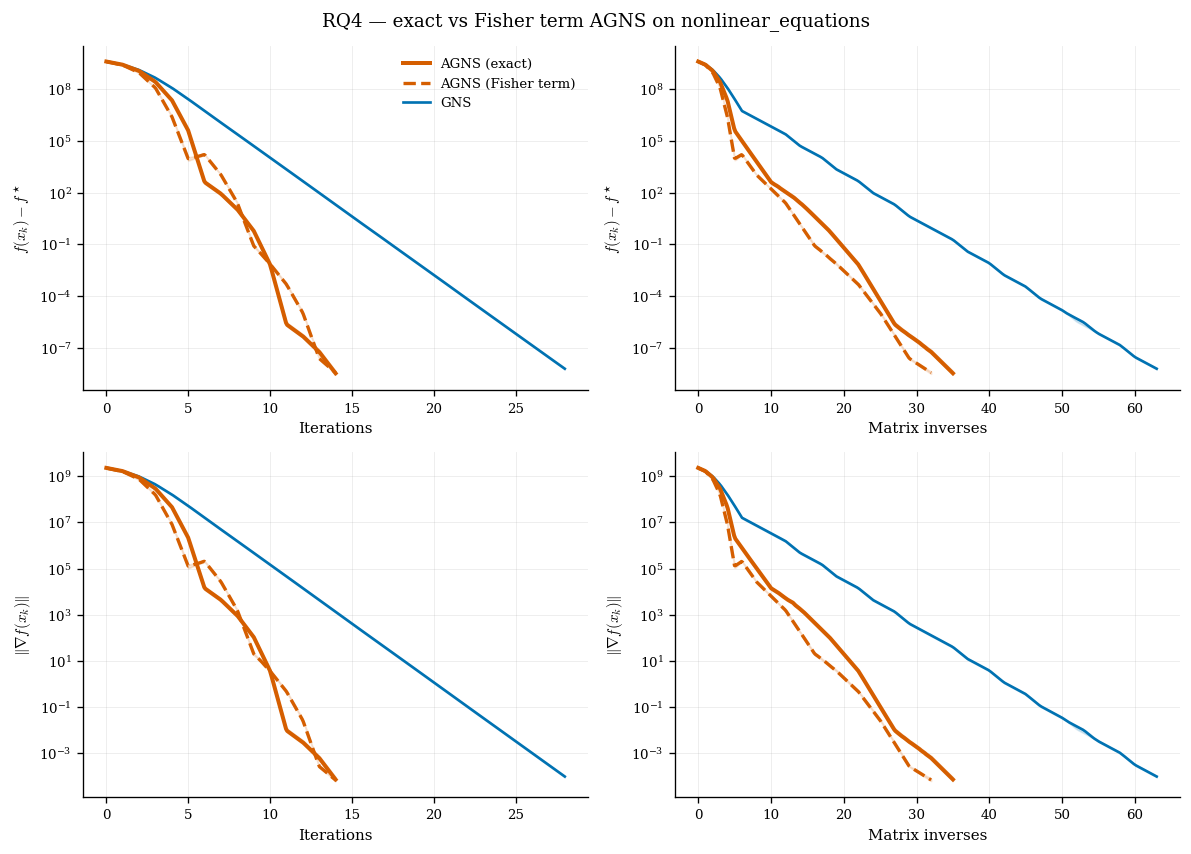

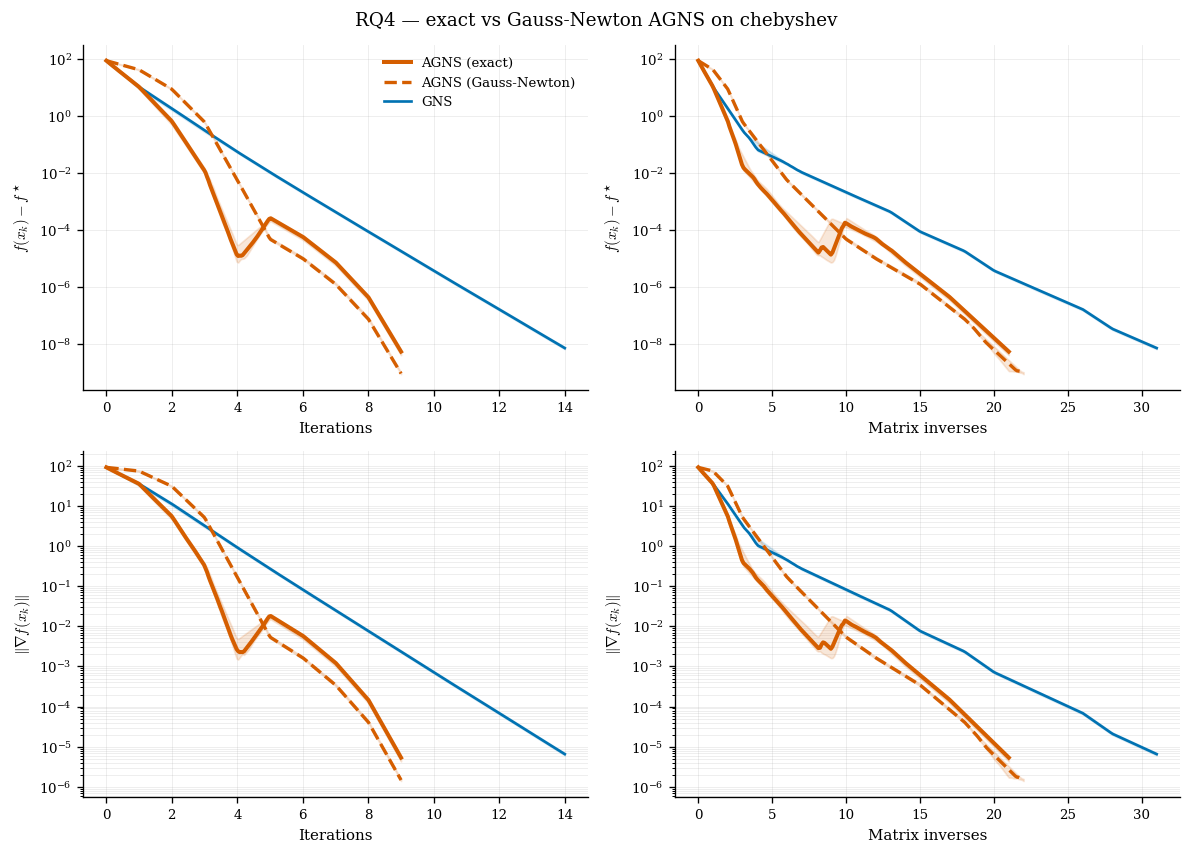

In [3]:
exact_variant = load_config("methods/agns_exact.yaml")
gns_variant = load_config("methods/gns.yaml")
rows = []
for fam in cfg["approx_families"]:
    oracle_spec = load_config(f"oracles/{fam['oracle']}.yaml")
    approx_variant = {
        **exact_variant,
        "approx": fam["approx"],
        "label": f"AGNS ({fam['label']})",
        "color": "#17becf",
    }
    variants = [exact_variant, approx_variant, gns_variant]
    res_f = experiment_result(
        oracle_spec,
        variants,
        n_iters=cfg["approx_iters"],
        seeds=seeds,
        cost_axes=("iterations", "matrix_inverses"),
        name=fam["oracle"],
    )
    convergence_figure(
        res_f,
        quantities=("func", "grad_norm"),
        title=f"RQ4 — exact vs {fam['label']} AGNS on {fam['oracle']}",
        save_as=f"fig4b_{fam['oracle']}.pdf",
        caption=(
            f"Approximate-Hessian AGNS on {fam['oracle']} ({fam['label']} approximation): residual "
            f"versus matrix inverses for exact-Hessian AGNS, approximate-Hessian AGNS, and GNS. "
            f"The approximate AGNS tracks the exact AGNS and still beats GNS. Median over 20 "
            f"instances, IQR band."
        ),
    )
    runs = res_f.method_runs
    med = {
        lab: float(
            np.median(
                [
                    c
                    for c in (
                        _cost_to_tolerance(h, h.get("f_star", 0.0), TOL, "matrix_inverses")
                        for h in hs
                    )
                    if np.isfinite(c)
                ]
            )
        )
        for lab, hs in runs.items()
    }
    mi_ex = cost_samples(res_f, exact_l, tolerance=TOL, cost_key="matrix_inverses")
    mi_ap = cost_samples(res_f, approx_variant["label"], tolerance=TOL, cost_key="matrix_inverses")
    margin_f = 0.15 * float(np.median(mi_ex))
    p_f, eq_f = tost_equivalence(mi_ap, mi_ex, margin=margin_f)
    rows.append(
        {
            "Family": fam["oracle"],
            "Approx": fam["label"],
            "AGNS exact": med[exact_l],
            "AGNS approx": med[approx_variant["label"]],
            "GNS": med["GNS"],
            "approx≈exact (TOST p)": p_f,
        }
    )
approx_tab = pd.DataFrame(rows)
display(approx_tab.round({"AGNS exact": 1, "AGNS approx": 1, "GNS": 1, "approx≈exact (TOST p)": 3}))
beats = ((approx_tab["AGNS approx"] < approx_tab["GNS"]).all())
display(
    Markdown(
        f"On both non-convex families the approximate-Hessian AGNS does what we hoped: it **tracks "
        f"the exact-Hessian AGNS** in matrix inverses (the two AGNS columns are close on each row) "
        f"and it **still beats GNS** "
        f"({'on every family' if beats else 'on most families'}). The acceleration is therefore not "
        f"an artefact of having the exact curvature — it survives precisely the cheap approximations "
        f"that make GNS practical in the first place, which is the property a deployable method "
        f"needs."
    )
)

## Conclusion

AGNS's acceleration survives an approximate Hessian where it matters. On the non-convex families — where AGNS's advantage over GNS is real — the approximate-Hessian AGNS tracks its exact counterpart and still beats GNS (the Fisher-term and Gauss-Newton variants are statistically equivalent to exact AGNS in solve count, TOST $p<0.05$). On the convex softmax the cheaper Weighted-Gauss-Newton surrogate actually costs *more* matrix inverses than the exact Hessian (76 vs 44, not statistically equivalent) though it still converges and stays close to GNS — but that is the regime where momentum has least to exploit. Combined with the earlier notebooks, the overall picture is now complete: explicit momentum accelerates GNS through the curvature-variation channel (RQ1), the adaptive restart is what makes that momentum safe and even necessary at scale (RQ2), the result is more economical than implicit acceleration across the regime studied (RQ3), and — on the non-convex families — it does not depend on having the exact Hessian (RQ4).